**Put your name and student ID here**

**An End-to-end Machine Learning Project**

# Get the Data

*Welcome to Machine Learning Housing Corp.! Your task is to predict median house values in Californian districts, given a number of features from these districts.*

# Python Environment

install python packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks/ANLY6500Fall2024/LC/M4P2EtEMLProject"

/content/drive/MyDrive/Colab Notebooks/ANLY6500Fall2024/LC/M4P2EtEMLProject


In [ ]:
%ls

cb_2023_us_state_500k.zip  Ch2_An_end_to_end_machine_learning_project_finisher.ipynb  housing.csv


In [ ]:
%pwd

'/content/drive/MyDrive/Colab Notebooks/ANLY6500Fall2024/LC/M4P2EtEMLProject'

In [ ]:
%pip install geopandas
%pip install contextily
%pip install mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 3.9 MB/s eta 0:00:00


import python packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

## Load the Data

In [ ]:
housing = pd.read_csv("housing.csv")

## Take a Quick Look at the Data Structure

In [ ]:
us_gdf = gpd.read_file("map/cb_2023_us_state_500k.shx")

In [ ]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
c = housing["total_rooms"]
c

,total_rooms
0,880.0
1,7099.0
2,1467.0
3,1274.0
4,1627.0
...,...
20635,1665.0
20636,697.0
20637,2254.0
20638,1860.0


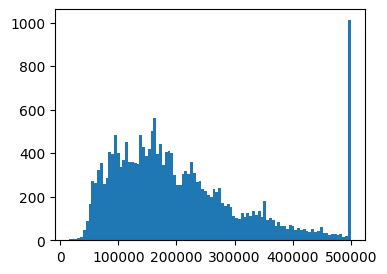

In [ ]:
fig = plt.figure(figsize=(4,3))

ax1 = plt.subplot(1,1,1)

plt.hist(housing["median_house_value"],bins=100)

plt.show()

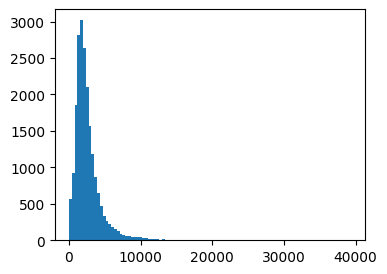

In [ ]:
fig = plt.figure(figsize=(4,3))

ax1 = plt.subplot(1,1,1)

plt.hist(c,bins=100)

plt.show()

In [ ]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
c = housing["ocean_proximity"]
vc = c.value_counts()
vc

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


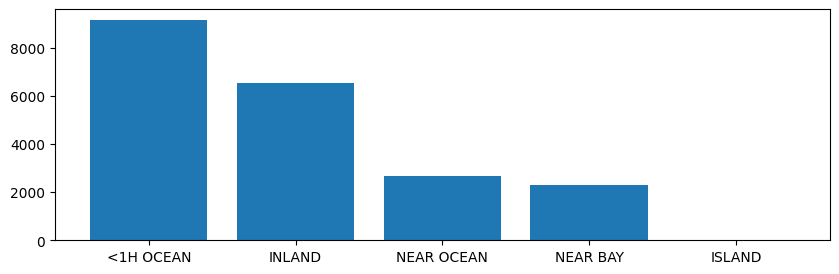

In [ ]:
fig = plt.figure(figsize=(10,3))

ax1 = plt.subplot(1,1,1)

plt.bar(vc.index,vc.values)

plt.show()

In [ ]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


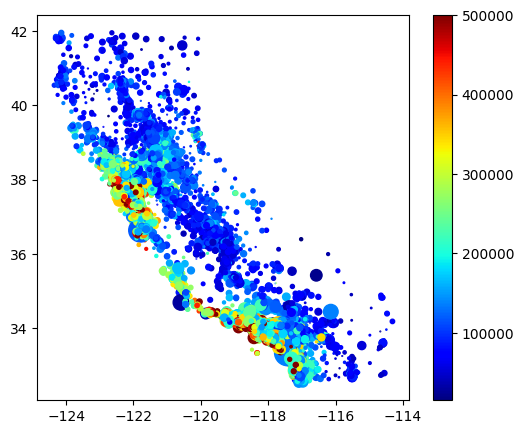

In [ ]:
fig = plt.figure(figsize=(6,5))

ax1 = plt.subplot(1,1,1)

sc1=plt.scatter(housing["longitude"],housing["latitude"],s=housing["population"]/100,c=housing["median_house_value"],cmap=plt.cm.jet)
plt.colorbar(sc1)

plt.show()

In [ ]:
us_gdf

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,35,00897535,0400000US35,35,NM,New Mexico,00,314198587197,726463919,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
1,46,01785534,0400000US46,46,SD,South Dakota,00,196341525171,3387709166,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
2,06,01779778,0400000US06,06,CA,California,00,403673296401,20291770234,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
3,21,01779786,0400000US21,21,KY,Kentucky,00,102266598312,2384223544,"MULTIPOLYGON (((-89.40565 36.52816, -89.39868 ..."
4,01,01779775,0400000US01,01,AL,Alabama,00,131185049346,4582326383,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
5,13,01705317,0400000US13,13,GA,Georgia,00,149485311347,4419673221,"MULTIPOLYGON (((-81.27939 31.30792, -81.27716 ..."
6,05,00068085,0400000US05,05,AR,Arkansas,00,134660466558,3122251184,"POLYGON ((-94.61792 36.49941, -94.61765 36.499..."
7,42,01779798,0400000US42,42,PA,Pennsylvania,00,115881839569,3397855215,"POLYGON ((-80.51989 40.90666, -80.51963 40.911..."
8,29,01779791,0400000US29,29,MO,Missouri,00,178052260322,2487519141,"POLYGON ((-95.77355 40.5782, -95.76853 40.5833..."
9,08,01779779,0400000US08,08,CO,Colorado,00,268418756810,1185758065,"POLYGON ((-109.06025 38.59933, -109.05954 38.7..."


In [ ]:
us_gdf.columns

Index(['STATEFP', 'STATENS', 'GEOIDFQ', 'GEOID', 'STUSPS', 'NAME', 'LSAD',
       'ALAND', 'AWATER', 'geometry'],
      dtype='object')

In [ ]:
us_gdf.set_index(["STUSPS"],drop=False,inplace=True)

In [ ]:
us_gdf

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
STUSPS,,,,,,,,,,
NM,35,00897535,0400000US35,35,NM,New Mexico,00,314198587197,726463919,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
SD,46,01785534,0400000US46,46,SD,South Dakota,00,196341525171,3387709166,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
CA,06,01779778,0400000US06,06,CA,California,00,403673296401,20291770234,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
KY,21,01779786,0400000US21,21,KY,Kentucky,00,102266598312,2384223544,"MULTIPOLYGON (((-89.40565 36.52816, -89.39868 ..."
AL,01,01779775,0400000US01,01,AL,Alabama,00,131185049346,4582326383,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
GA,13,01705317,0400000US13,13,GA,Georgia,00,149485311347,4419673221,"MULTIPOLYGON (((-81.27939 31.30792, -81.27716 ..."
AR,05,00068085,0400000US05,05,AR,Arkansas,00,134660466558,3122251184,"POLYGON ((-94.61792 36.49941, -94.61765 36.499..."
PA,42,01779798,0400000US42,42,PA,Pennsylvania,00,115881839569,3397855215,"POLYGON ((-80.51989 40.90666, -80.51963 40.911..."
MO,29,01779791,0400000US29,29,MO,Missouri,00,178052260322,2487519141,"POLYGON ((-95.77355 40.5782, -95.76853 40.5833..."


In [ ]:
import contextily as ctx

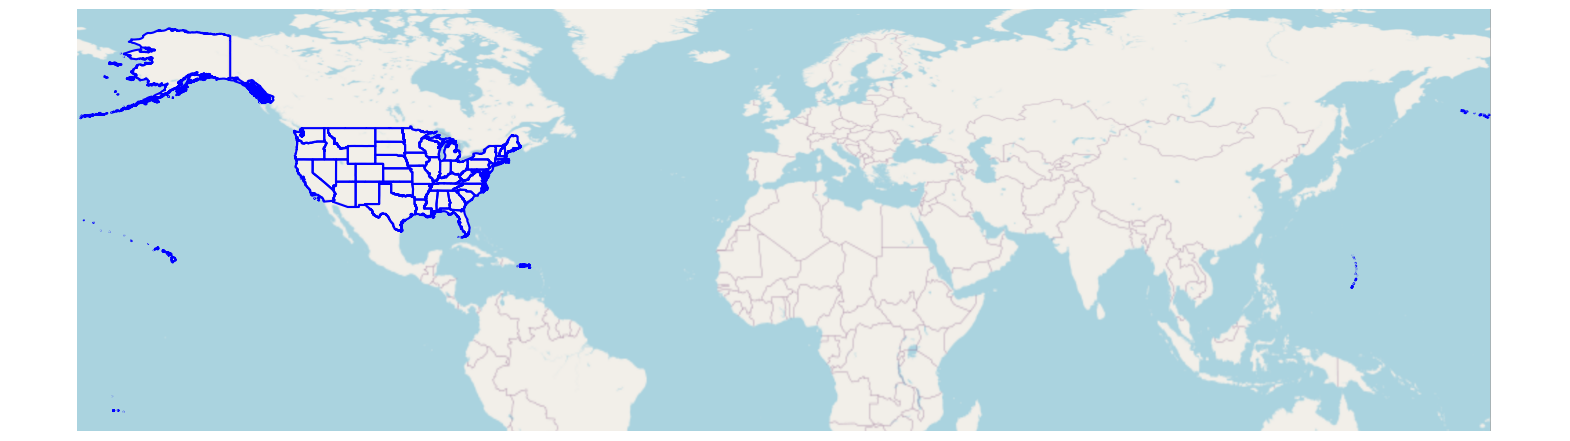

In [ ]:
fig = plt.figure(figsize=(20,10))

ax1 = plt.subplot(1,1,1)

us_gdf.boundary.plot(ax=ax1,color="blue")

ctx.add_basemap(ax=ax1,crs=us_gdf.crs,attribution="",source=ctx.providers.OpenStreetMap.Mapnik,)

plt.axis(False)

plt.show()

In [ ]:
ca_gdf = us_gdf.loc[["CA"]]
ca_gdf

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
STUSPS,,,,,,,,,,
CA,06,01779778,0400000US06,06,CA,California,00,403673296401,20291770234,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."


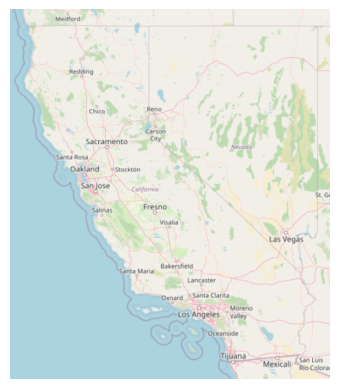

In [ ]:
fig = plt.figure()

ax1 = plt.subplot(1,1,1)

ca_gdf.boundary.plot(ax=ax1,color="none")

ctx.add_basemap(ax=ax1,crs=us_gdf.crs,attribution="",source=ctx.providers.OpenStreetMap.Mapnik,)

plt.axis(False)

plt.show()

In [ ]:
# prepare for the ML algorithms
# process the missing values
# drop the column (no good)
# drop the row (good) use this one
# fill the value (mean,median,) #

In [ ]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing.dropna(subset=["total_bedrooms"],axis=0) # delete rows with missing values

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
housing.drop(["total_bedrooms"],axis=1)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
# 3
avg = housing["total_bedrooms"].mean()
avg

537.8705525375618

In [ ]:
housing["total_bedrooms"].fillna(avg).info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: total_bedrooms
Non-Null Count  Dtype  
--------------  -----  
20640 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB


In [ ]:
housing.dropna(subset=["total_bedrooms"],axis=0,inplace=True)

In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [ ]:
# process the categorical columns
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

In [ ]:
housing["ocean_proximity"]

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
...,...
20635,INLAND
20636,INLAND
20637,INLAND
20638,INLAND


In [ ]:
vc = housing["ocean_proximity"].value_counts()
vc

,count
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


In [ ]:
# ordinal encoder
ordinal_encoder= OrdinalEncoder()

In [ ]:
ordinal_encoder.fit(housing[["ocean_proximity"]])

OrdinalEncoder()

In [ ]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [ ]:
ordinal_encoder.categories

'auto'

In [ ]:
ordinal_encoder.transform(housing[["ocean_proximity"]])

array([[3.],
       [3.],
       [3.],
       ...,
       [1.],
       [1.],
       [1.]])

In [ ]:
# one hot
# 5 columns 0 1
onehot_encoder = OneHotEncoder()
onehot_encoder.fit(housing[["ocean_proximity"]])

OneHotEncoder()

In [ ]:
X_P1 = onehot_encoder.transform(housing[["ocean_proximity"]]).toarray()
X_P1

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [ ]:
onehot_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [ ]:
X_P1_df= pd.DataFrame(X_P1,columns=onehot_encoder.get_feature_names_out(),index=housing["ocean_proximity"].index)
X_P1_df

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...
20635,0.0,1.0,0.0,0.0,0.0
20636,0.0,1.0,0.0,0.0,0.0
20637,0.0,1.0,0.0,0.0,0.0
20638,0.0,1.0,0.0,0.0,0.0


In [ ]:
housing_df = pd.merge(left=housing,right=X_P1_df,left_index=True,right_index=True)
housing_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,0.0,1.0,0.0,0.0,0.0


In [ ]:
# split the data into training and testing
from sklearn.model_selection import train_test_split


In [ ]:
train_df,test_df=train_test_split(housing_df,test_size=0.2,stratify=housing_df["ocean_proximity"])

In [ ]:
train_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13418,-122.53,37.97,44.0,3595.0,953.0,1831.0,910.0,2.6036,287500.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
3176,-117.95,34.07,37.0,1987.0,399.0,1279.0,378.0,4.1172,176500.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
1456,-122.39,41.41,23.0,910.0,199.0,370.0,169.0,1.7448,80100.0,INLAND,0.0,1.0,0.0,0.0,0.0
7894,-121.90,37.36,47.0,1007.0,245.0,581.0,240.0,2.9545,237500.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
9203,-119.81,36.28,24.0,544.0,112.0,442.0,106.0,3.1071,56100.0,INLAND,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9515,-118.15,33.92,28.0,1038.0,252.0,912.0,245.0,2.5875,161200.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
5524,-119.97,38.93,24.0,856.0,185.0,388.0,108.0,3.1806,107200.0,INLAND,0.0,1.0,0.0,0.0,0.0
16764,-118.39,34.20,17.0,2594.0,1028.0,3950.0,973.0,2.0348,177200.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
4361,-121.64,36.67,28.0,256.0,66.0,214.0,60.0,3.0197,137500.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0


In [ ]:
# train and test split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_df,test_df = train_test_split(housing_df,test_size=0.2,stratify=housing_df["ocean_proximity"]) # 0 - 1
train_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
3057,-122.13,37.47,30.0,1480.0,294.0,1126.0,301.0,4.9830,166700.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
14630,-122.20,37.84,35.0,2865.0,460.0,1072.0,443.0,7.4882,319300.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
11391,-118.37,36.19,10.0,443.0,111.0,48.0,21.0,3.1250,71300.0,INLAND,0.0,1.0,0.0,0.0,0.0
16253,-117.03,33.18,17.0,5391.0,886.0,2732.0,830.0,5.1771,212800.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
3481,-117.81,33.73,19.0,5471.0,1345.0,2828.0,1247.0,3.5719,252800.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11280,-122.42,40.32,16.0,1978.0,375.0,961.0,333.0,2.6827,83900.0,INLAND,0.0,1.0,0.0,0.0,0.0
13080,-118.36,33.88,22.0,1388.0,336.0,930.0,287.0,2.7981,275000.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
8214,-122.35,37.96,35.0,1326.0,346.0,1023.0,295.0,2.0724,97700.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
10693,-122.24,37.76,52.0,2567.0,436.0,1119.0,415.0,4.6094,229300.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0


In [ ]:
# min max
# standard scaler

# scale: most of the time, only scale on X (features)
# learn (fit) from the train data
# apply (transform) to both train and test

In [ ]:
# min max: (x-min)/(max-min) [0-1]
# starnd: normal (x-mean)/std_deviation -3,3

In [ ]:
train_df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [ ]:
X_P1_columns=['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',]

In [ ]:
X_train_P1=train_df[X_P1_columns]
X_train_P1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
3057,-122.13,37.47,30.0,1480.0,294.0,1126.0,301.0,4.9830
14630,-122.20,37.84,35.0,2865.0,460.0,1072.0,443.0,7.4882
11391,-118.37,36.19,10.0,443.0,111.0,48.0,21.0,3.1250
16253,-117.03,33.18,17.0,5391.0,886.0,2732.0,830.0,5.1771
3481,-117.81,33.73,19.0,5471.0,1345.0,2828.0,1247.0,3.5719
...,...,...,...,...,...,...,...,...
11280,-122.42,40.32,16.0,1978.0,375.0,961.0,333.0,2.6827
13080,-118.36,33.88,22.0,1388.0,336.0,930.0,287.0,2.7981
8214,-122.35,37.96,35.0,1326.0,346.0,1023.0,295.0,2.0724
10693,-122.24,37.76,52.0,2567.0,436.0,1119.0,415.0,4.6094


In [ ]:
X_P2_columns=['ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

In [ ]:
X_train_P2=train_df[X_P2_columns]
X_train_P2

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
3057,0.0,0.0,0.0,1.0,0.0
14630,0.0,0.0,0.0,1.0,0.0
11391,0.0,1.0,0.0,0.0,0.0
16253,1.0,0.0,0.0,0.0,0.0
3481,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
11280,0.0,1.0,0.0,0.0,0.0
13080,1.0,0.0,0.0,0.0,0.0
8214,0.0,0.0,0.0,1.0,0.0
10693,0.0,0.0,0.0,1.0,0.0


In [ ]:
y_train=train_df["median_house_value"]
y_train

,median_house_value
3057,166700.0
14630,319300.0
11391,71300.0
16253,212800.0
3481,252800.0
...,...
11280,83900.0
13080,275000.0
8214,97700.0
10693,229300.0


In [ ]:
# test
X_test_P1= test_df[X_P1_columns]
X_test_P1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
2784,-118.22,33.98,34.0,2225.0,753.0,2980.0,736.0,1.6685
908,-122.07,37.86,23.0,1025.0,205.0,263.0,191.0,3.1200
11215,-118.05,33.83,24.0,4316.0,678.0,2286.0,665.0,5.7018
1061,-121.97,37.54,31.0,1949.0,344.0,986.0,322.0,4.6349
13266,-117.90,33.97,23.0,7353.0,1255.0,4014.0,1124.0,5.4155
...,...,...,...,...,...,...,...,...
6254,-120.47,34.94,17.0,1368.0,308.0,642.0,303.0,1.8633
17628,-118.99,35.40,43.0,2225.0,392.0,890.0,374.0,4.0208
2366,-117.64,33.65,4.0,6842.0,1512.0,3256.0,1439.0,5.4132
707,-117.93,33.74,5.0,639.0,197.0,666.0,197.0,3.3017


In [ ]:
X_test_P2 = test_df[X_P2_columns]

In [ ]:
y_test=test_df["median_house_value"]

In [ ]:
# train
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [ ]:
minmax_scaler = MinMaxScaler()

In [ ]:
minmax_scaler.fit(X_train_P1)

MinMaxScaler()

In [ ]:
X_train_P1_scaled=minmax_scaler.transform(X_train_P1)

In [ ]:
minmax_scaler.transform(X_test_P1)

array([[0.61055777, 0.15302869, 0.64705882, ..., 0.08343844, 0.12086828,
        0.08059199],
       [0.22709163, 0.565356  , 0.43137255, ..., 0.0072872 , 0.03124486,
        0.18069406],
       [0.62749004, 0.1370882 , 0.45098039, ..., 0.06398722, 0.10919257,
        0.35874678],
       ...,
       [0.66832669, 0.11795962, 0.05882353, ..., 0.09117408, 0.23647426,
        0.3388436 ],
       [0.63944223, 0.12752391, 0.07843137, ..., 0.01858236, 0.03223154,
        0.19322492],
       [0.11354582, 0.84697131, 0.29411765, ..., 0.00417613, 0.0098668 ,
        0.06035089]])

In [ ]:
X_train_P1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
3057,-122.13,37.47,30.0,1480.0,294.0,1126.0,301.0,4.9830
14630,-122.20,37.84,35.0,2865.0,460.0,1072.0,443.0,7.4882
11391,-118.37,36.19,10.0,443.0,111.0,48.0,21.0,3.1250
16253,-117.03,33.18,17.0,5391.0,886.0,2732.0,830.0,5.1771
3481,-117.81,33.73,19.0,5471.0,1345.0,2828.0,1247.0,3.5719
...,...,...,...,...,...,...,...,...
11280,-122.42,40.32,16.0,1978.0,375.0,961.0,333.0,2.6827
13080,-118.36,33.88,22.0,1388.0,336.0,930.0,287.0,2.7981
8214,-122.35,37.96,35.0,1326.0,346.0,1023.0,295.0,2.0724
10693,-122.24,37.76,52.0,2567.0,436.0,1119.0,415.0,4.6094


In [ ]:
standard_scaler = StandardScaler()

In [ ]:
standard_scaler.fit(X_train_P1)

StandardScaler()

In [ ]:
X_train_P1_scaled = standard_scaler.transform(X_train_P1)

In [ ]:
X_train_P1_scaled

array([[-1.27977901,  0.8597322 ,  0.11208971, ..., -0.2619417 ,
        -0.51769402,  0.58393632],
       [-1.3147193 ,  1.03256515,  0.50968928, ..., -0.30924234,
        -0.14755449,  1.90718026],
       [ 0.59701344,  0.26182362, -1.47830859, ..., -1.20620254,
        -1.24754661, -0.39745728],
       ...,
       [-1.38959134,  1.08861908,  0.50968928, ..., -0.35216329,
        -0.53333371, -0.95343947],
       [-1.33468518,  0.99519586,  1.86152783, ..., -0.26807327,
        -0.22053974,  0.3866012 ],
       [ 0.05294329,  0.45801237, -1.23974884, ..., -0.61844835,
        -0.66105792, -0.13335782]])

In [ ]:
X_test_P1_scaled = standard_scaler.transform(X_test_P1)

In [ ]:
# train models

In [ ]:
X_train = np.hstack([X_train_P1_scaled,X_train_P2.to_numpy()])
X_train.shape

(16346, 13)

In [ ]:
X_test =np.hstack([X_test_P1_scaled,X_test_P2.to_numpy()])

In [ ]:
# regression
#
from sklearn.linear_model import LinearRegression

In [ ]:
l_m=LinearRegression(n_jobs=-1)

In [ ]:
l_m.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [ ]:
# test
y_test_lm_predicted = l_m.predict(X_test)
y_test_lm_predicted

array([123524.95806376, 193779.90500251, 271466.5418282 , ...,
       301223.2083591 , 166623.80954431,  35275.25823109])

In [ ]:
test_df["Linear"]=y_test_lm_predicted/y_test-1

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
lm_rmse=mean_squared_error(y_true=y_test,y_pred=y_test_lm_predicted)
lm_rmse

4558821664.304656

In [ ]:
y_test_lm_predicted/y_test-1

,median_house_value
2784,-0.040955
908,0.250193
11215,-0.053134
1061,0.324776
13266,0.166390
...,...
6254,0.583388
17628,1.152596
2366,0.390689
707,0.904272


In [ ]:
np.average(np.abs(y_test_lm_predicted/y_test-1))

0.28474397175454086

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
tree_m=DecisionTreeRegressor()
tree_m.fit(X_train,y_train)

DecisionTreeRegressor()

In [ ]:
y_test_treem_predicted= tree_m.predict(X_test)

In [ ]:
treem_rmse=mean_squared_error(y_true=y_test,y_pred=y_test_treem_predicted)
treem_rmse

4255291114.9867873

In [ ]:
np.average(np.abs(y_test_treem_predicted/y_test-1))

0.2263378062126637

In [ ]:
test_df["Decision Tree"]=y_test_treem_predicted/y_test-1

In [ ]:
#
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
knn_m=KNeighborsRegressor()

In [ ]:
knn_m.fit(X_train,y_train)

KNeighborsRegressor()

In [ ]:
y_test_knnm_predicted = knn_m.predict(X_test)

In [ ]:
knnm_rmse=mean_squared_error(y_true=y_test,y_pred=y_test_knnm_predicted)
knnm_rmse

3587700848.2774453

In [ ]:
np.average(np.abs(y_test_knnm_predicted/y_test-1))

0.21849660548603592

In [ ]:
test_df["KNN"]=y_test_knnm_predicted/y_test-1

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
forest_m = RandomForestRegressor()

In [ ]:
forest_m.fit(X_train,y_train)

RandomForestRegressor()

In [ ]:
y_test_forestm_predicted = forest_m.predict(X_test)

In [ ]:
forestm_rmse=mean_squared_error(y_true=y_test,y_pred=y_test_forestm_predicted)
forestm_rmse

2233230321.144188

In [ ]:
np.average(np.abs(y_test_forestm_predicted/y_test-1))

0.171147995330138

In [ ]:
test_df["Random Forest"]=y_test_forestm_predicted/y_test-1

In [ ]:
# svr
from sklearn.svm import SVR

In [ ]:
svr_m=SVR()

In [ ]:
svr_m.fit(X_train,y_train)

SVR()

In [ ]:
y_test_svrm_predicted = svr_m.predict(X_test)

In [ ]:
svrm_rmse=mean_squared_error(y_true=y_test,y_pred=y_test_svrm_predicted)
svrm_rmse

13865985282.843594

In [ ]:
np.average(np.abs(y_test_svrm_predicted/y_test-1))

0.526170490912635

In [ ]:
test_df["SVR"]=y_test_svrm_predicted/y_test-1

In [ ]:
# cross validation
from sklearn.model_selection import cross_val_score

In [ ]:
lm_c_rmses=-cross_val_score(l_m,X_train,y_train,scoring="neg_mean_squared_error",cv=5)

In [ ]:
lm_c_rmses.mean()

4774602586.140276

In [ ]:
test_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,Linear,Decision Tree,KNN,Random Forest,SVR
2784,-118.22,33.98,34.0,2225.0,753.0,2980.0,736.0,1.6685,128800.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,-0.040955,-0.045807,0.173602,0.136460,0.397609
908,-122.07,37.86,23.0,1025.0,205.0,263.0,191.0,3.1200,155000.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0,0.250193,0.330968,0.303613,0.387123,0.159845
11215,-118.05,33.83,24.0,4316.0,678.0,2286.0,665.0,5.7018,286700.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,-0.053134,-0.238926,-0.132543,-0.100105,-0.368178
1061,-121.97,37.54,31.0,1949.0,344.0,986.0,322.0,4.6349,196200.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,0.324776,0.042304,0.321814,0.123486,-0.080120
13266,-117.90,33.97,23.0,7353.0,1255.0,4014.0,1124.0,5.4155,213200.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,0.166390,0.040807,0.186773,0.202749,-0.152764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6254,-120.47,34.94,17.0,1368.0,308.0,642.0,303.0,1.8633,109400.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,0.583388,0.277879,0.918830,0.442258,0.642939
17628,-118.99,35.40,43.0,2225.0,392.0,890.0,374.0,4.0208,90400.0,INLAND,0.0,1.0,0.0,0.0,0.0,1.152596,-0.029867,-0.096681,0.025188,0.991385
2366,-117.64,33.65,4.0,6842.0,1512.0,3256.0,1439.0,5.4132,216600.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,0.390689,-0.054478,0.205263,0.298879,-0.166556
707,-117.93,33.74,5.0,639.0,197.0,666.0,197.0,3.3017,87500.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,0.904272,0.629714,1.059886,1.032549,1.058947


In [ ]:
test_housing_df=gpd.GeoDataFrame(test_df,geometry=gpd.points_from_xy(test_df["longitude"],test_df["latitude"]),crs=ca_gdf.crs)

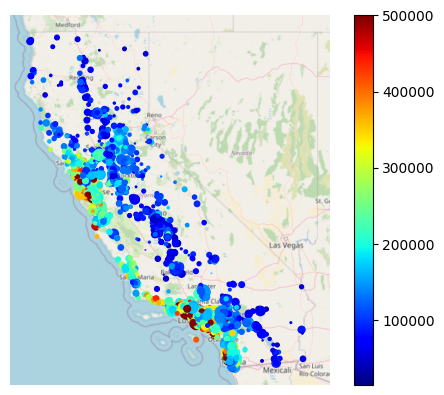

In [ ]:
fig = plt.figure()

ax1 = plt.subplot(1,1,1)

ca_gdf.boundary.plot(ax=ax1,color="none")

ctx.add_basemap(ax=ax1,crs=us_gdf.crs,attribution="",source=ctx.providers.OpenStreetMap.Mapnik,)

test_housing_df.plot(ax=ax1,markersize=test_housing_df["population"]/100,column=test_housing_df["median_house_value"],cmap=plt.cm.jet,legend=True )

plt.axis(False)

plt.savefig("fig1.png",dpi=600)

plt.show()

In [ ]:
test_housing_df.explore(column="median_house_value",cmap="jet")

## Create a Test Set

# Discover and Visualize the Data to Gain Insights

## Visualizing Geographical Data

## Looking for Correlations

## Experimenting with Attribute Combinations

# Prepare the Data for Machine Learning Algorithms

Let's revert to the original training set and separate the target (note that `strat_train_set.drop()` creates a copy of `strat_train_set` without the column, it doesn't actually modify `strat_train_set` itself, unless you pass `inplace=True`):

## Data Cleaning

In the book 3 options are listed to handle the NaN values:

```python
housing.dropna(subset=["total_bedrooms"], inplace=True)    # option 1

housing.drop("total_bedrooms", axis=1)       # option 2

median = housing["total_bedrooms"].median()  # option 3
housing["total_bedrooms"].fillna(median, inplace=True)
```

For each option, we'll create a copy of `housing` and work on that copy to avoid breaking `housing`. We'll also show the output of each option, but filtering on the rows that originally contained a NaN value.

In [ ]:
# housing.dropna(subset=["total_bedrooms"], inplace=True)    # option 1
# housing.drop("total_bedrooms", axis=1)       # option 2
# median = housing["total_bedrooms"].median()  # option 3
# housing["total_bedrooms"].fillna(median, inplace=True)

Separating out the numerical attributes to use the `"median"` strategy (as it cannot be calculated on text attributes like `ocean_proximity`):

Check that this is the same as manually computing the median of each attribute:

Transform the training set:

Now let's drop some outliers:

If you wanted to drop outliers, you would run the following code:

In [ ]:
#housing = housing.iloc[outlier_pred == 1]
#housing_labels = housing_labels.iloc[outlier_pred == 1]

## Handling Text and Categorical Attributes

Now let's preprocess the categorical input feature, `ocean_proximity`:

By default, the `OneHotEncoder` class returns a sparse array, but we can convert it to a dense array if needed by calling the `toarray()` method:

Alternatively, you can set `sparse=False` when creating the `OneHotEncoder`:

## Feature Scaling

What if we replace each value with its percentile?

# Select and Train a Model

## Training and Evaluating on the Training Set

Let's try the full preprocessing pipeline on a few training instances:

Compare against the actual values:

## Better Evaluation Using Cross-Validation

**Warning:** the following cell may take a few minutes to run:

Let's compare this RMSE measured using cross-validation (the "validation error") with the RMSE measured on the training set (the "training error"):

The training error is much lower than the validation error, which usually means that the model has overfit the training set. Another possible explanation may be that there's a mismatch between the training data and the validation data, but it's not the case here, since both came from the same dataset that we shuffled and split in two parts.

# Fine-Tune Your Model

## Grid Search

## Randomized Search

## Evaluate Your System on the Test Set

## Model persistence using joblib

Save the final model:

In [ ]:
import joblib

joblib.dump(final_model, "my_california_housing_model.model")

Now you can deploy this model to production. For example, the following code could be a script that would run in production:

In [ ]:
import joblib

final_model_reloaded = joblib.load("my_california_housing_model.model")



You could use pickle instead, but joblib is more efficient.